In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.linear_model import LogisticRegression

In [3]:
df = pd.read_csv("Downloads/Heart Stroke Prediction ML Project/healthcare-dataset-stroke-data.csv")

In [3]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [5]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [6]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [7]:
def get_smoke_count(smoking_status):
    mask=df['smoking_status']==smoking_status
    return df[mask]

In [8]:
get_smoke_count('Unknown')

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1
13,8213,Male,78.0,0,1,Yes,Private,Urban,219.84,NaN,Unknown,1
19,25226,Male,57.0,0,1,No,Govt_job,Urban,217.08,NaN,Unknown,1
23,64778,Male,82.0,0,1,Yes,Private,Rural,208.30,32.5,Unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5098,579,Male,9.0,0,0,No,children,Urban,71.88,17.5,Unknown,0
5101,36901,Female,45.0,0,0,Yes,Private,Urban,97.95,24.5,Unknown,0
5103,22127,Female,18.0,0,0,No,Private,Urban,82.85,46.9,Unknown,0
5104,14180,Female,13.0,0,0,No,children,Rural,103.08,18.6,Unknown,0


In [9]:
df["smoking_status"].value_counts()

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

In [10]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [11]:
null_values = df['bmi'].isnull().sum()
null_values

201

In [12]:
null_percentage = df['bmi'].isnull().mean()*100
null_percentage

3.9334637964774952

In [13]:
column_mean = df['bmi'].mean()
df['bmi'].fillna(column_mean, inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_11960\3726938499.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['bmi'].fillna(column_mean, inplace=True)


0       36.600000
1       28.893237
2       32.500000
3       34.400000
4       24.000000
          ...    
5105    28.893237
5106    40.000000
5107    30.600000
5108    25.600000
5109    26.200000
Name: bmi, Length: 5110, dtype: float64

In [14]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

In [15]:
columns = ['gender','ever_married','work_type', 'Residence_type','smoking_status']

for col in columns:
    unique_values = df[col].unique()
    print(f"Unique values for {col}:{unique_values}")

Unique values for gender:<StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
Unique values for ever_married:<StringArray>
['Yes', 'No']
Length: 2, dtype: str
Unique values for work_type:<StringArray>
['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
Length: 5, dtype: str
Unique values for Residence_type:<StringArray>
['Urban', 'Rural']
Length: 2, dtype: str
Unique values for smoking_status:<StringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str


In [16]:
df['gender'].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [17]:
# In gender column there is only one value for other so we replace it with male
df['gender'] = df['gender'].replace('Other', 'Male')

In [18]:
df['gender'].value_counts()

gender
Female    2994
Male      2116
Name: count, dtype: int64

In [19]:
mask1 = df[['gender','ever_married','work_type', 'Residence_type','smoking_status']].nunique()
mask1

gender            2
ever_married      2
work_type         5
Residence_type    2
smoking_status    4
dtype: int64

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


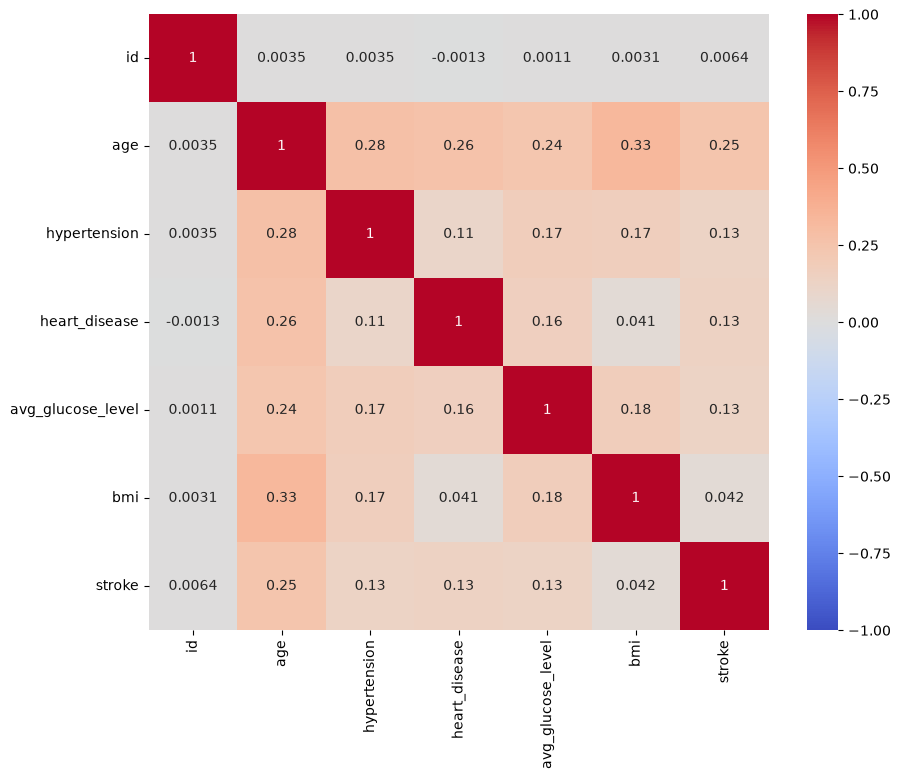

In [21]:
corr_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            vmin=-1,
            vmax=1)

plt.show()

# Feature Engineering

In [22]:
# Creating age group categories

print(f'maximum age variable: {df["age"].max()}')
print(f'minimum age variable: {df["age"].min()}')
print(f'Number of age variable: {df["age"].nunique()}')

maximum age variable: 82.0
minimum age variable: 0.08
Number of age variable: 104


In [23]:
# collapse age group categories
ranges = [0,13,18,45,60,100]
group_names = ['Children','Teens','Adults','Mid-adults','Elderly']
df['age_group'] = pd.cut(df['age'],bins=ranges,labels=group_names)
df['age_group'].unique()

['Elderly', 'Mid-adults', 'Adults', 'Children', 'Teens']
Categories (5, str): ['Children' < 'Teens' < 'Adults' < 'Mid-adults' < 'Elderly']

In [24]:
# For BMI

print(f'maximum age variable: {df["bmi"].max()}')
print(f'minimum age variable: {df["bmi"].min()}')
print(f'Number of age variable: {df["bmi"].nunique()}')

maximum age variable: 97.6
minimum age variable: 10.3
Number of age variable: 418


In [25]:
# collapse bmi into fewer groups

ranges = [0,19,25,30,100]
group_names = ['Underweight', 'Normal', 'Overweight', 'Obesity']
df['bmi_group'] = pd.cut(df['bmi'],bins=ranges,labels=group_names)
df['bmi_group'].unique()

['Obesity', NaN, 'Normal', 'Overweight', 'Underweight']
Categories (4, str): ['Underweight' < 'Normal' < 'Overweight' < 'Obesity']

In [26]:
# for avg glucose level

print(f'maximum age variable: {df["avg_glucose_level"].max()}')
print(f'minimum age variable: {df["avg_glucose_level"].min()}')
print(f'Number of age variable: {df["avg_glucose_level"].nunique()}')

maximum age variable: 271.74
minimum age variable: 55.12
Number of age variable: 3979


In [27]:
ranges = [0, 70, 99, 125, 280]
group_names = ['Low', 'Normal', 'High', 'Very_high']
df['avg_glucose_level_group'] = pd.cut(df['avg_glucose_level'],bins=ranges,labels=group_names)
df['avg_glucose_level_group'].unique()

['Very_high', 'High', 'Normal', 'Low']
Categories (4, str): ['Low' < 'Normal' < 'High' < 'Very_high']

# Exploratory data analysis(EDA)

In [28]:
df['stroke_label'] = df['stroke'].map({
    0: 'No Stroke',
    1: 'Stroke'
})

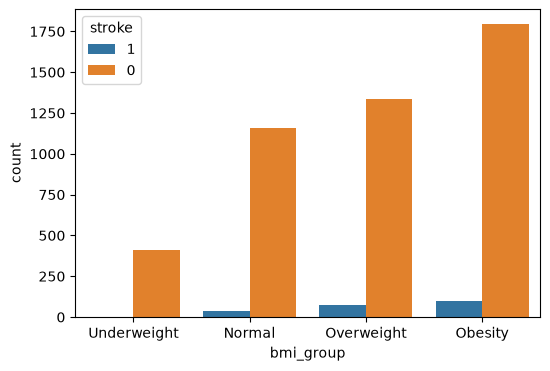

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='bmi_group', hue=df['stroke'].astype(str))
plt.show()

([<matplotlib.patches.Rectangle object at 0x0000025BA3D94950>, <matplotlib.patches.Rectangle object at 0x0000025BA3D8D910>], ['Stroke', 'No Stroke'])


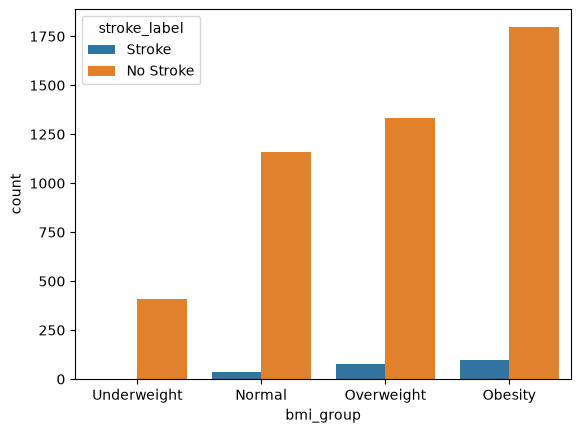

In [30]:
ax = sns.countplot(data=df, x='bmi_group', hue='stroke_label')
print(ax.get_legend_handles_labels())
plt.show()

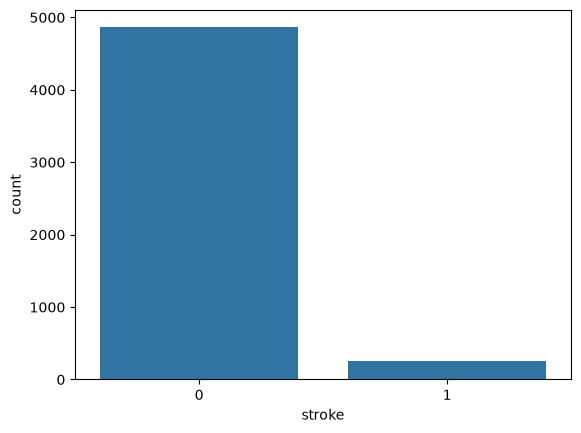

In [31]:
sns.countplot(x='stroke',data=df)
plt.show()

In [32]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group,bmi_group,avg_glucose_level_group,stroke_label
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Elderly,Obesity,Very_high,Stroke
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,Elderly,NaN,Very_high,Stroke
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Elderly,Obesity,High,Stroke
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Mid-adults,Obesity,Very_high,Stroke
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Elderly,Normal,Very_high,Stroke


In [33]:
#checking ki environment mein seaborn aur matplotlib versions ke beech compatibility issue toh nhi
import seaborn as sns
import matplotlib

print(sns.__version__)
print(matplotlib.__version__)

0.13.2
3.11.0


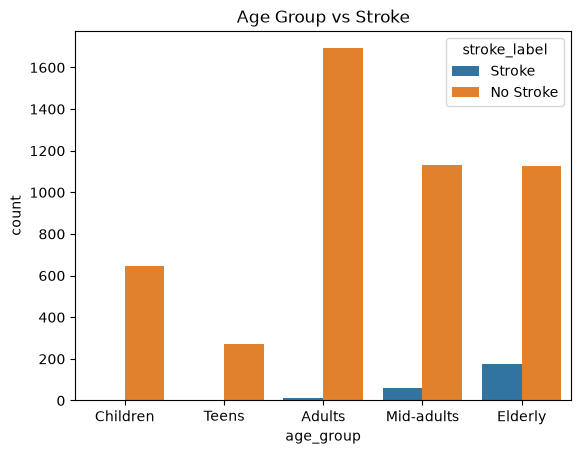

In [34]:
df['stroke_label'] = df['stroke'].map({0: 'No Stroke', 1: 'Stroke'})

sns.countplot(x='age_group', hue='stroke_label', data=df)
plt.title("Age Group vs Stroke")
plt.show()

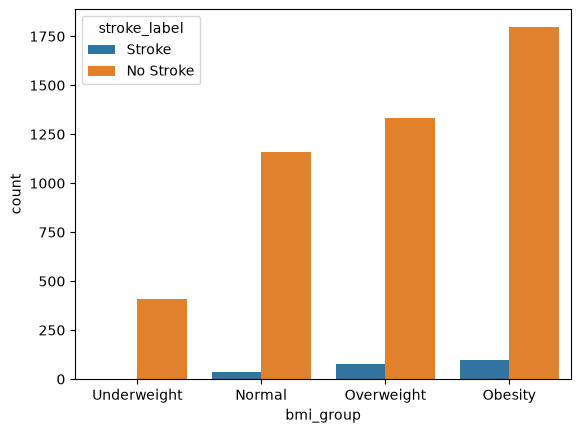

In [35]:
sns.countplot(x='bmi_group', hue='stroke_label', data=df)
plt.show()

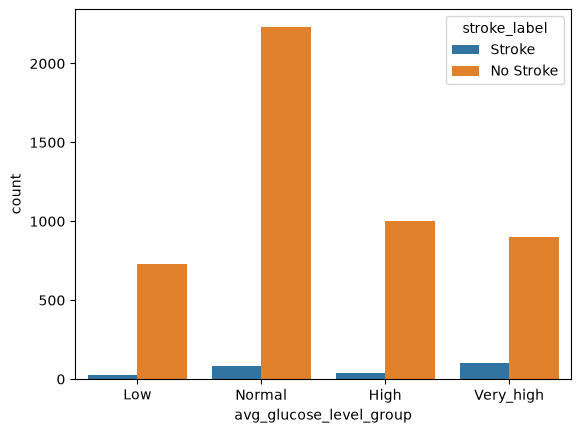

In [36]:
sns.countplot(x='avg_glucose_level_group',hue='stroke_label',data=df)
plt.show()

<Axes: xlabel='heart_disease', ylabel='age'>

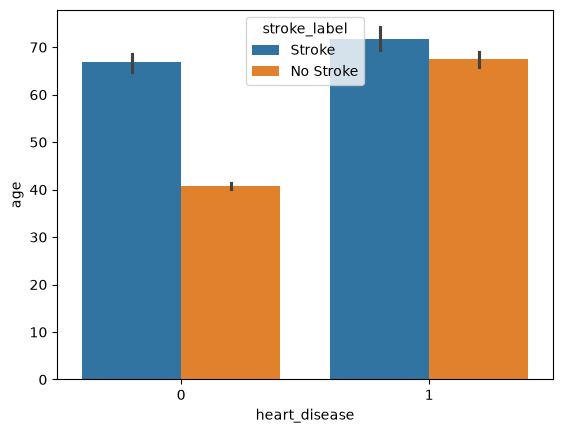

In [37]:
sns.barplot(x='heart_disease',y='age',data=df,hue='stroke_label')

In [38]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group,bmi_group,avg_glucose_level_group,stroke_label
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Elderly,Obesity,Very_high,Stroke
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,Elderly,NaN,Very_high,Stroke
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Elderly,Obesity,High,Stroke
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Mid-adults,Obesity,Very_high,Stroke
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Elderly,Normal,Very_high,Stroke
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0,Elderly,NaN,Normal,No Stroke
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0,Elderly,Obesity,Very_high,No Stroke
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0,Adults,Obesity,Normal,No Stroke
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0,Mid-adults,Overweight,Very_high,No Stroke


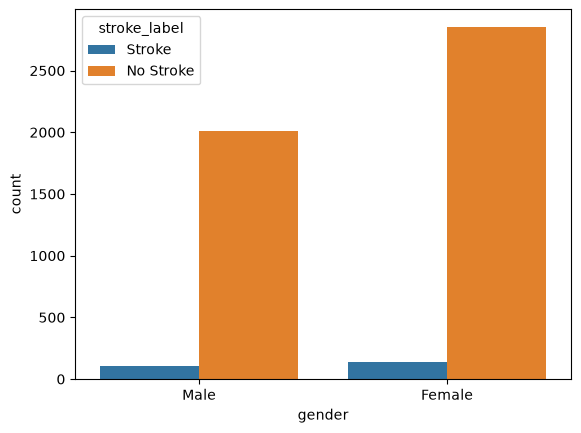

In [39]:
sns.countplot(x='gender',hue='stroke_label',data=df)
plt.show()

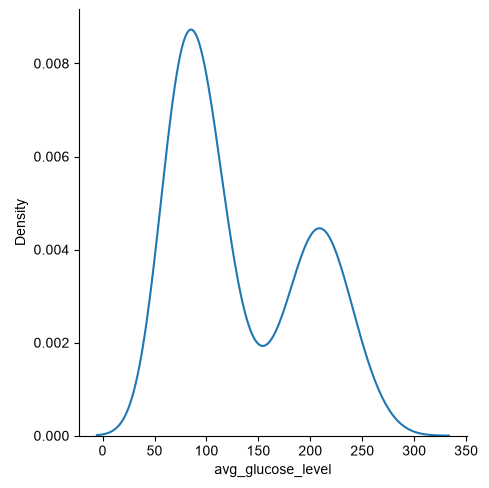

In [40]:
stroke = df[df['stroke']==1]
sns.displot(stroke['avg_glucose_level'], kind='kde')
sns.set_style('darkgrid')
plt.show()

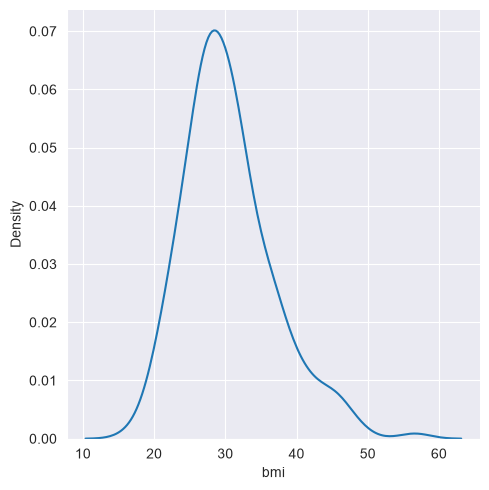

In [41]:
stroke = df[df['stroke']==1]
sns.displot(stroke['bmi'], kind='kde')
sns.set_style('darkgrid')
plt.show()

# Preprocessing

### Binary Encoding

In [42]:
#Instantiate LabelEncoder
labelencoder = LabelEncoder()

#Binary Encoding(encoding object columns with 2 unique values)
binary_cols =  ['ever_married', 'Residence_type', 'gender']
for col in binary_cols:
    df[col]=labelencoder.fit_transform(df[col])

### Label Encoding

In [43]:
categorical_cols = ['age_group', 'bmi_group', 'avg_glucose_level_group']

label_encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

## One hot encoding

In [44]:
#Encode object columns that more than 2 unique values
df = pd.get_dummies(df, columns=['work_type', 'smoking_status'], drop_first=True)

In [45]:
df

,id,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,...,bmi_group,avg_glucose_level_group,stroke_label,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,9046,1,67.0,0,1,1,1,228.69,36.6,1,...,1,3,Stroke,False,True,False,False,True,False,False
1,51676,0,61.0,0,0,1,0,202.21,NaN,1,...,4,3,Stroke,False,False,True,False,False,True,False
2,31112,1,80.0,0,1,1,0,105.92,32.5,1,...,1,0,Stroke,False,True,False,False,False,True,False
3,60182,0,49.0,0,0,1,1,171.23,34.4,1,...,1,3,Stroke,False,True,False,False,False,False,True
4,1665,0,79.0,1,0,1,0,174.12,24.0,1,...,0,3,Stroke,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,0,80.0,1,0,1,1,83.75,NaN,0,...,4,2,No Stroke,False,True,False,False,False,True,False
5106,44873,0,81.0,0,0,1,1,125.20,40.0,0,...,1,3,No Stroke,False,False,True,False,False,True,False
5107,19723,0,35.0,0,0,1,0,82.99,30.6,0,...,1,2,No Stroke,False,False,True,False,False,True,False
5108,37544,1,51.0,0,0,1,0,166.29,25.6,0,...,2,3,No Stroke,False,True,False,False,True,False,False


In [46]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [47]:
df['stroke'].value_counts(normalize=True) * 100

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64

#### It looks like our data is imbalanced, so we have to resample it.

In [48]:
# handle Imbalance data
stroke_0=df[df['stroke']==0]
stroke_1=df[df['stroke']==1]

In [49]:
# resample
from sklearn.utils import resample
df_upsampled=resample(stroke_1,replace=True,n_samples=4700)

In [50]:
new_df=pd.concat([stroke_0,df_upsampled])
from sklearn.utils import shuffle
new_df=shuffle(new_df)

In [58]:
new_df['bmi'] = new_df['bmi'].fillna(new_df['bmi'].mean())

In [51]:
new_df['stroke'].value_counts()

stroke
0    4861
1    4700
Name: count, dtype: int64

In [59]:
X = new_df.drop(columns=['id', 'stroke', 'stroke_label'])
y = new_df['stroke']

In [60]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(6692, 18)
(2869, 18)
(6692,)
(2869,)


In [54]:
from sklearn.preprocessing import MinMaxScaler

Scaler = MinMaxScaler()
# fit the scaler to the train set, it will learn parameters
Scaler.fit(X_train)

#transform train and test set

X_train_scaled = Scaler.transform(X_train)
X_test_scaled = Scaler.transform(X_test)

In [61]:
print(X_train.isnull().sum())

gender                            0
age                               0
hypertension                      0
heart_disease                     0
ever_married                      0
Residence_type                    0
avg_glucose_level                 0
bmi                               0
age_group                         0
bmi_group                         0
avg_glucose_level_group           0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
dtype: int64


### Now lets compare accuracy using Different Algorithms

# 1) Logistic Regression

In [62]:
logistic_reg = LogisticRegression()

In [65]:
logistic_reg.fit(X_train, y_train)

C:\Users\Admin\anaconda3\envs\stroke_project\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [66]:
y_pred = logistic_reg.predict(X_test)

In [67]:
log_reg_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {log_reg_accuracy}")

Accuracy: 0.786336702683862


#### lets evaluate Accuracy of  model

In [68]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.72      0.77      1438
           1       0.75      0.85      0.80      1431

    accuracy                           0.79      2869
   macro avg       0.79      0.79      0.79      2869
weighted avg       0.79      0.79      0.79      2869



#### sample explaination
![](https://i.stack.imgur.com/Wsz2t.png)

# 2) Decision Tree

In [69]:
# Create the Decision Tree Classifier
decision_tree_classifier = DecisionTreeClassifier()

In [70]:
# Train the classifier on the training data
decision_tree_classifier.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [71]:
# Make predictions on the test set
y_pred = decision_tree_classifier.predict(X_test)

In [72]:
# Calculate the accuracy of the classifier
dt_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {dt_accuracy}")



Accuracy: 0.9686301847333566


# Visualization Of  Decision Tree

In [73]:
from sklearn.tree import plot_tree, export_text

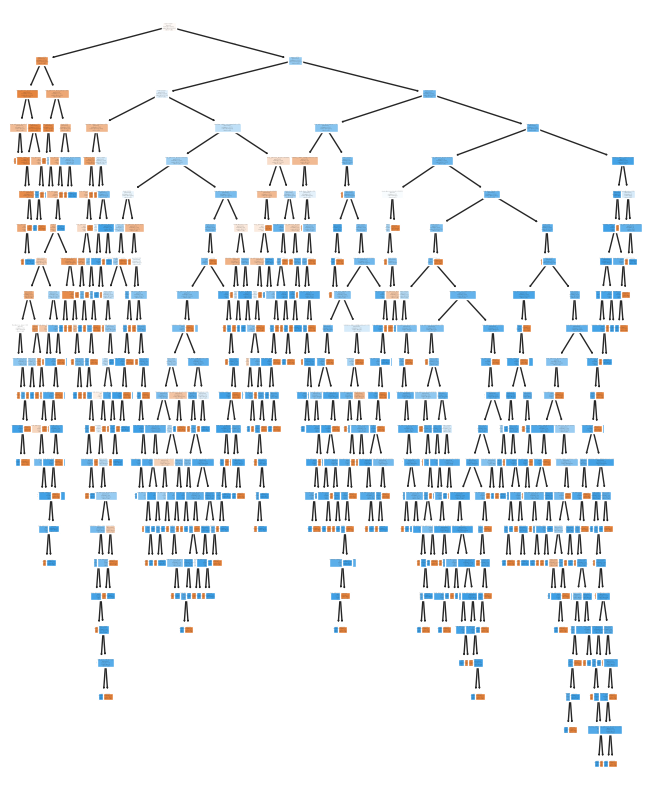

In [74]:
plt.figure(figsize=(8,10))
plot_tree(decision_tree_classifier, feature_names=X.columns,class_names=True, filled=True);

#### lets evaluate Accuracy of model

In [75]:
predictions = decision_tree_classifier.predict(X_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1438
           1       0.94      1.00      0.97      1431

    accuracy                           0.97      2869
   macro avg       0.97      0.97      0.97      2869
weighted avg       0.97      0.97      0.97      2869



# 3) Random forest Classifier

In [76]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)
y_pred = rf_classifier.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {rf_accuracy}")

Accuracy: 0.9909376089229697


# Visualization Of Random Forest

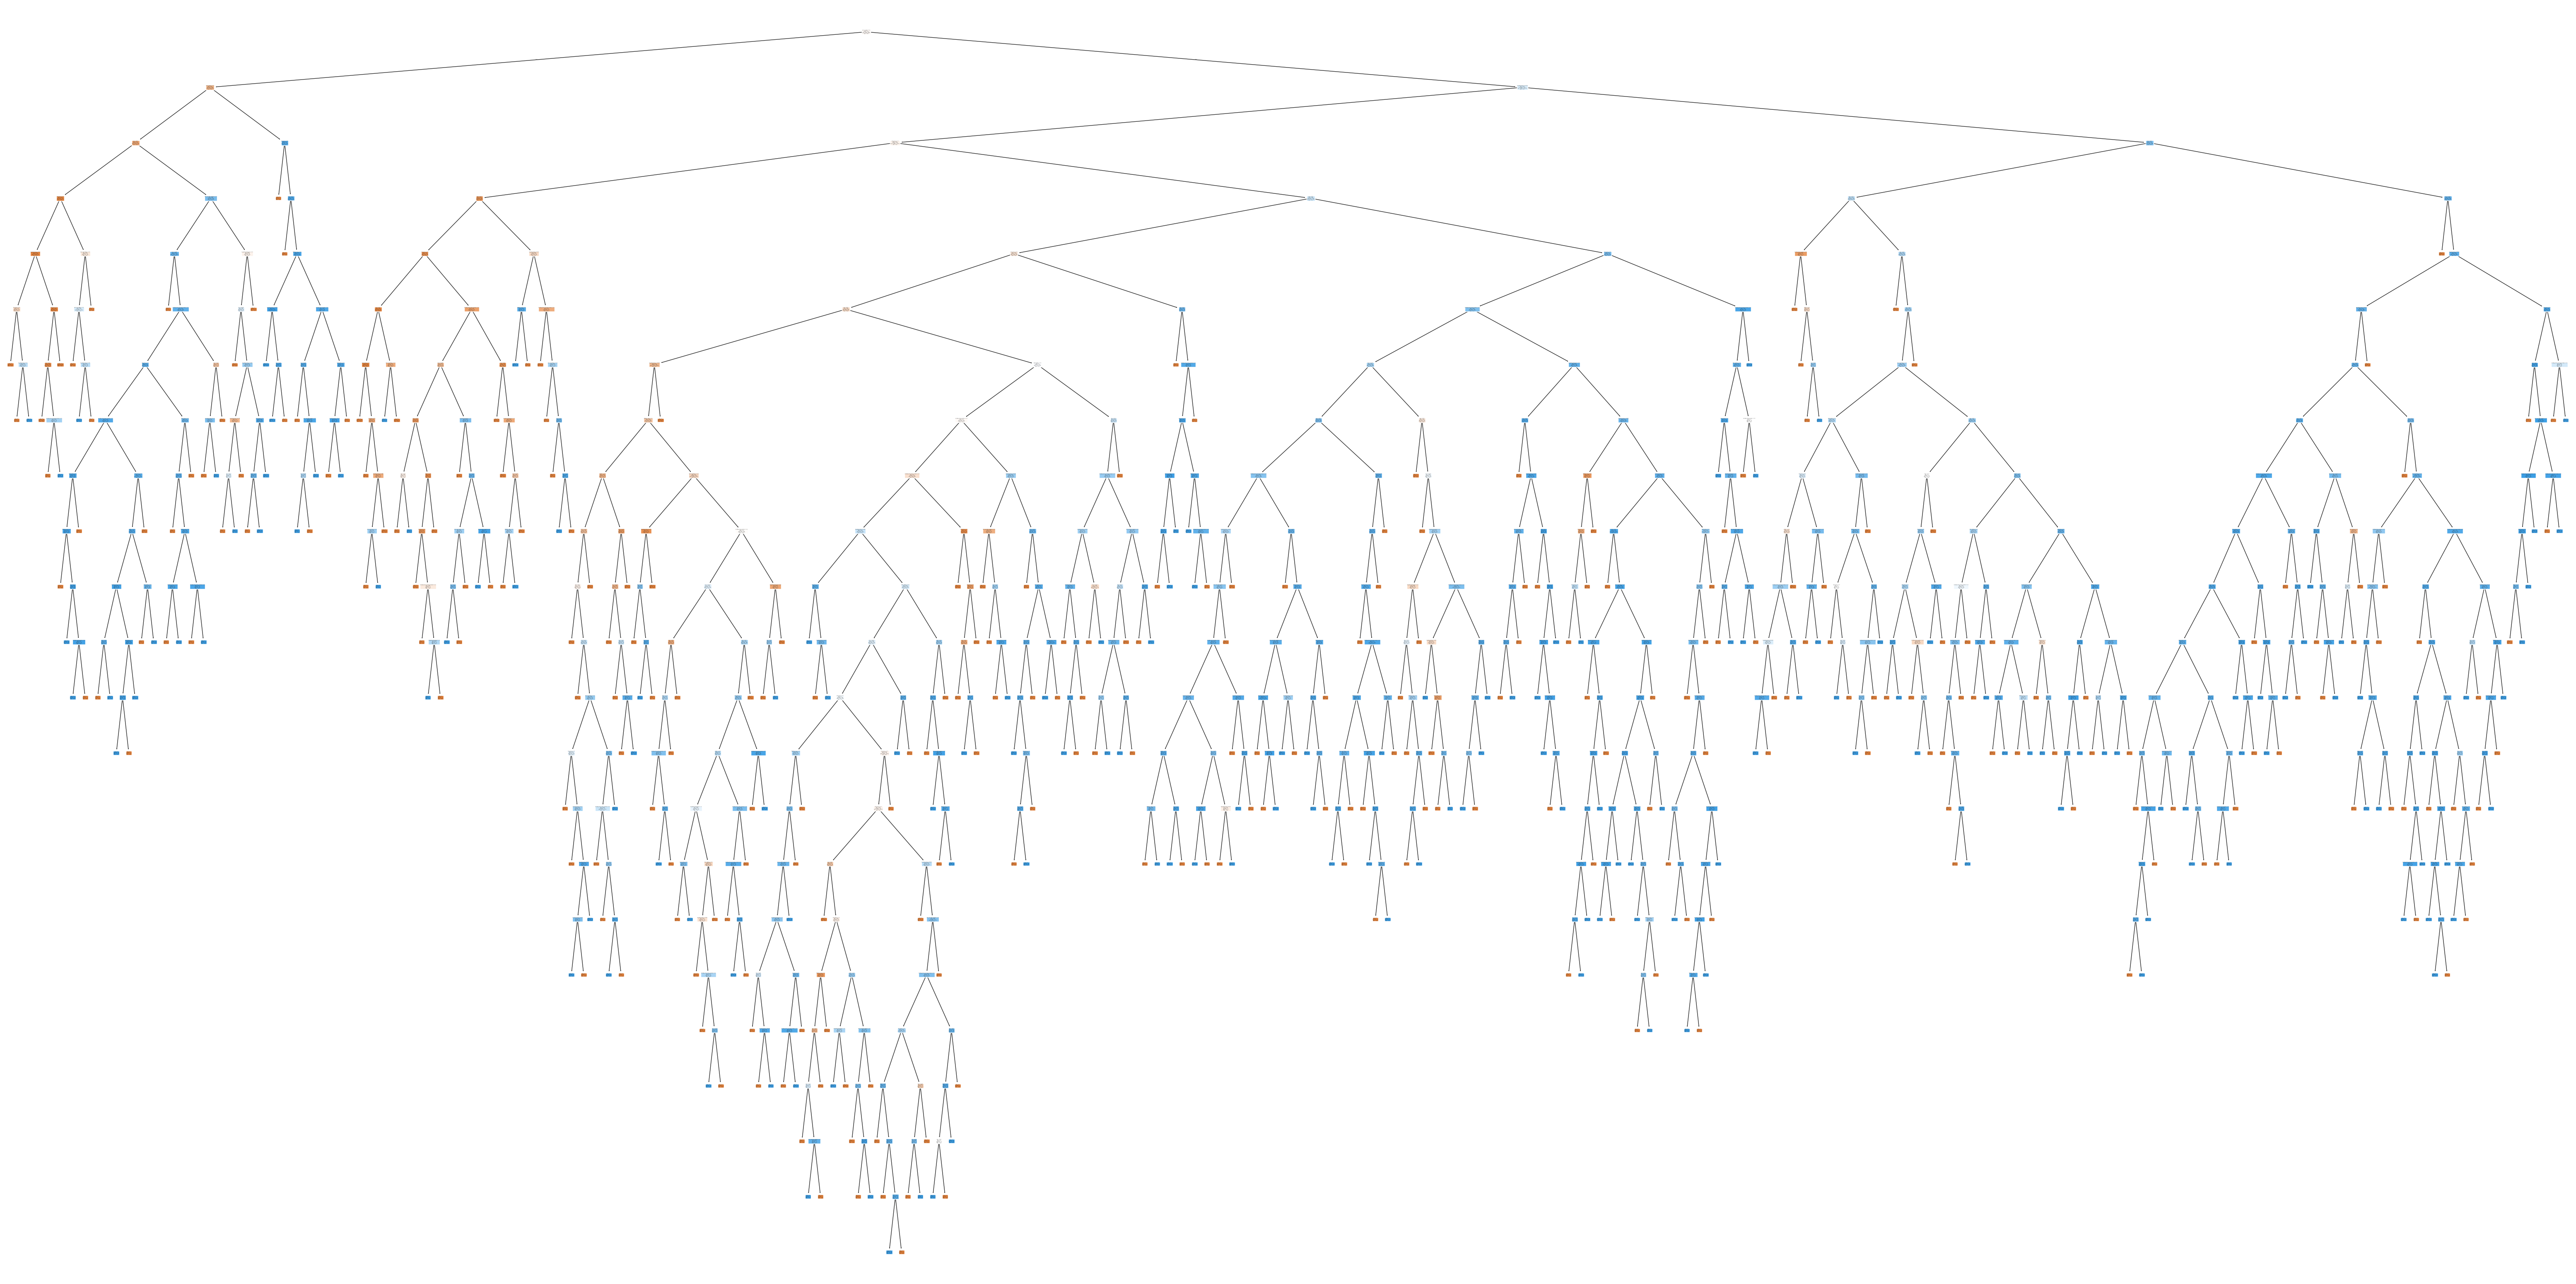

In [77]:
from sklearn.tree import plot_tree
plt.figure(figsize=(80,40))
plot_tree(rf_classifier.estimators_[0], feature_names = X.columns,class_names=True,filled=True);

##### lets evaluate Accuracy of model

In [78]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[1412   26]
 [   0 1431]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1438
           1       0.98      1.00      0.99      1431

    accuracy                           0.99      2869
   macro avg       0.99      0.99      0.99      2869
weighted avg       0.99      0.99      0.99      2869



## Hyperparameter Tunning By GridSearchCV Method.

In [79]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

In [80]:
params = {
    'max_depth': [2,3,5,10,20],
    'min_samples_leaf': [5,10,20,50,100,200],
    'n_estimators': [10,25,30,50,100,200]
}

In [81]:
from sklearn.model_selection import GridSearchCV

In [82]:
grid_search = GridSearchCV(estimator=rf,
                           param_grid=params,
                           cv = 5,
                           n_jobs=-1, scoring="f1_weighted")

In [83]:

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 3, ...], 'min_samples_leaf': [5, 10, ...], 'n_estimators': [10, 25, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default

In [84]:
grid_search.best_score_

0.9434177232459611

In [85]:
grid_search.cv_results_ 

{'mean_fit_time': array([0.16915274, 0.31337442, 0.32946286, 0.55222392, 1.05607357,
        2.04826951, 0.18292723, 0.36378694, 0.41603856, 0.53596821,
        0.98162923, 2.09246774, 0.17025208, 0.41720033, 0.39087138,
        0.56521878, 1.1049705 , 2.1853478 , 0.21027651, 0.41549869,
        0.41782727, 0.56673684, 1.11369357, 2.14205484, 0.18836145,
        0.40350838, 0.39133682, 0.49886904, 0.99019046, 2.05392823,
        0.18146553, 0.43373942, 0.42948852, 0.57564135, 1.18570848,
        2.20242758, 0.20093389, 0.40414605, 0.45104551, 0.50095859,
        1.08182645, 2.28214941, 0.20126615, 0.39851475, 0.43250942,
        0.53633842, 1.05480013, 2.18543296, 0.21472611, 0.44066277,
        0.39065361, 0.52758799, 1.0526895 , 2.28305588, 0.19516306,
        0.46395941, 0.40139346, 0.52219539, 1.03526697, 2.20174174,
        0.21557236, 0.42438326, 0.42267017, 0.53587017, 1.05661774,
        2.22791581, 0.20302849, 0.43342853, 0.44090581, 0.57481103,
        1.16249352, 2.24243498,

In [86]:
rf_best = grid_search.best_estimator_
rf_best

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [87]:
rf_best.score(X_train,y_train)

0.9726539151225344

In [88]:
rf_best.score(X_test,y_test)

0.953990937608923

In [89]:
yhat = rf_best.predict(X_test)

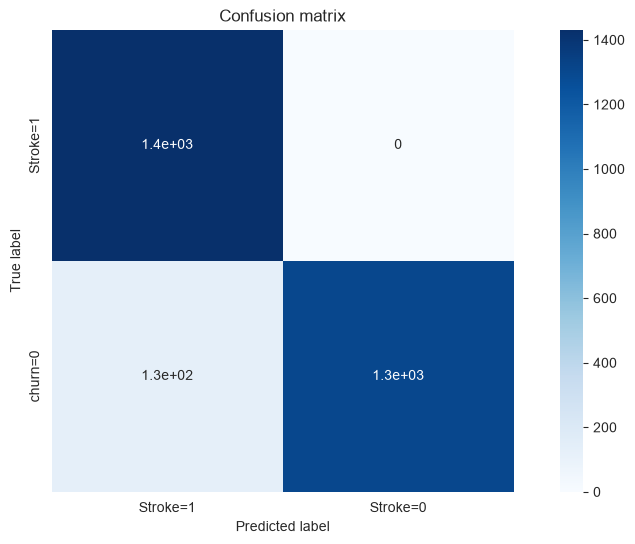

In [90]:
cnf_matrix = confusion_matrix(y_test, yhat, labels=[1,0])
plt.figure(figsize=(12,6))
sns.heatmap(cnf_matrix, annot=True, xticklabels=['Stroke=1','Stroke=0'],yticklabels=['Stroke=1','churn=0'], cmap='Blues', square=True);
plt.xlabel('Predicted label');
plt.ylabel('True label');
plt.title('Confusion matrix');

In [91]:
print(confusion_matrix(y_test,yhat))
print(classification_report(y_test,yhat))

[[1306  132]
 [   0 1431]]
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      1438
           1       0.92      1.00      0.96      1431

    accuracy                           0.95      2869
   macro avg       0.96      0.95      0.95      2869
weighted avg       0.96      0.95      0.95      2869



# Final Accuracy

In [92]:
from sklearn.metrics import accuracy_score

print("Accuracy :", accuracy_score(y_test, yhat))

Accuracy : 0.953990937608923


# Conclusion

This project successfully developed a Stroke Prediction model using the Random Forest algorithm.
The dataset was cleaned, analyzed, and preprocessed through feature engineering, resampling, encoding, train-test splitting, and feature scaling.
The trained model achieved approximately 95% accuracy and showed good performance based on the confusion matrix and classification report. 
